In [ ]:
pip install mesa_reader

In [ ]:
pip install pygyre

In [ ]:
profile_number=3 #<-------- choose profile number!

In [ ]:
#@title import
import matplotlib.pyplot as plt
import numpy as np

import mesa_reader as mr
import pygyre as pg
from scipy.integrate import cumulative_trapezoid

In [ ]:
#@title ploting functions
def plot_format(color=False):
    #plt.rcParams.update(plt.rcParamsDefault)
    plt.style.use('default')
    #plt.rcParams['savefig.dpi'] = 300

    sSize = 10
    mSize = 12
    lSize = 16


    plt.rc('font', size=sSize)
    plt.rc('axes', titlesize=lSize,labelsize=mSize)
    plt.rc('xtick', labelsize=sSize)
    plt.rc('ytick', labelsize=sSize)
    plt.rc('legend', fontsize=sSize)
    plt.rc('figure', titlesize=lSize, figsize= (10,6))
plot_format()

def get_dnu_from_mod(modes0,numax,k = 0.9638,b = -1.7145, plot=True):

    radial_n    =modes0['n_p']
    radial_freqs=modes0['freq'].real

    width = np.exp(k*np.log(numax) + b)
    weight = np.exp(-(radial_freqs-numax)**2./(2*width**2.))

    p = np.polyfit(radial_n, radial_freqs, 1, w=weight) #dnu*(n+eps)
    dnu = p[0]

    if plot:
        plt.figure()
        plt.errorbar(radial_n,radial_freqs,yerr=weight,marker='o')
        plt.plot(radial_n,np.polyval(p,radial_n),'r')
    return dnu

def plot_echelle(summary,nu_max,dnu,axEchelle=False
                 ,colors = ['tab:green', 'mediumpurple', 'saddlebrown', 'purple']
                 ,marker = ['D','o','^','o']):

    if not axEchelle:
        plt.figure()
        axEchelle=plt.gca()

    for ell in np.unique(summary['l']):
        nus = summary[(summary['l'] == ell) & (summary['m'] == 0) ]
        axEchelle.scatter(nus['freq'].real % dnu, nus['freq'].real, marker=marker[ell],
                    facecolor=colors[ell], edgecolor='k',linewidth=0.5,
                    alpha=1, s=nus['E_p']*150,
                    label='l='+str(ell))

        #include rotational splitting
        nus = summary[(summary['l'] == ell) & (summary['m'] != 0) ]
        plt.scatter(nus['freq'].real % dnu, nus['freq'].real, marker=marker[ell]
                    ,facecolor='None', edgecolor=colors[ell],linewidth=0.5,
                    alpha=1, s=nus['E_p']*150)
                    #label=str(ell))


    axEchelle.legend(loc='lower right')
    axEchelle.axhline(nu_max, ls='--', c='darkgray', zorder=-99)
    axEchelle.set_xlim([0, dnu])

    axEchelle.set_ylabel(r'Frequency $\nu/\mu\rm{Hz}$')
    axEchelle.set_xlabel(r'$\nu\; \rm{mod}\; \Delta\nu/\mu\rm{Hz}$ ')#+f'{str(dnu)}')
    axEchelle.set_title('Echelle Diagram', size=20)

    return axEchelle


#%% prop
def plot_propagation_diagram(profile=False,detail=False,axProp=False,nu_max=False,xlim=(0,0.25),ylim=(0.005,1e12),legend=True):

    if not axProp:
        plt.figure()
        axProp=plt.gca()
        plt.subplots_adjust(bottom=0.1,top=0.95,left=0.08,right=0.98,hspace=0,wspace=0)

    if profile:
        brunt=profile.brunt_N2*1e6**2
        lamb =profile.lamb_S2*1e6**2
        x    =profile.R/np.max(profile.R)
        omega=np.nan

    elif detail:
        omega = detail.meta['omega']
        l       = detail.meta['l']
        x       = detail['x']
        V       = detail['V_2']*detail['x']**2
        As      = detail['As']
        c_1     = detail['c_1']
        Gamma_1 = detail['Gamma_1']

        brunt = detail['As']/detail['c_1']
        lamb = l*(l+1)*Gamma_1/(V*c_1)

    axProp.text(axProp.get_xlim()[1]-0.5,axProp.get_ylim()[1]-0.2,'p-mode cavity',fontsize=14,color='blue',transform=axProp.transAxes)
    if xlim[0]<0.01:
        axProp.text(axProp.get_xlim()[0]+0.15,axProp.get_ylim()[0]+0.1,'g-mode cavity',fontsize=14,color='red',transform=axProp.transAxes)

    axProp.set_yscale('log')
    #axProp.set_xscale('log')

    axProp.plot(x, brunt, label='$N^2$',color='k',ls='--')
    axProp.plot(x, lamb,  label=r'$S_{{l={}}}^2$'.format(1),color='k')

    axProp.axhline(nu_max**2,ls='-.',lw=2,color='gray',label='ν$_{max}^2$')
    # axProp.axhline(omega.real**2,ls='-.',lw=2,color='m',)

    if legend:
        axProp.legend()

    if xlim:
        axProp.set_xlim(xlim)
    if ylim:
        axProp.set_ylim(ylim)
    axProp.autoscale(False)

    axProp.fill_between(x, brunt,axProp.get_ylim()[1],color='lightblue')
    axProp.fill_between(x, lamb ,axProp.get_ylim()[0],color='orange'
                       ,alpha=0.5)
    axProp.fill_between(x, brunt,lamb,color='white')

    axProp.set_xlabel('r/R')
    axProp.set_ylabel(r'Frequency² $\nu²/\mu\rm{Hz}$²')


def plot_gyre_grid(profile,summary,detail_directory,nu_max,dnu,scale_xi=False,figsize=(14,7),fileformat='h5',addHRD=False):
    if scale_xi:
        from scipy.integrate import cumulative_trapezoid
    l=1
    modesl = summary[summary['l'] == l]
    n_numax   = modesl['n_p'][np.argmin(np.abs(modesl['freq'].real-nu_max))]

    modesl_numax=modesl[modesl['n_p']==n_numax]
    idx_p_dominated_mode=np.argmax(modesl_numax['E_p'])
    idx_g_dominated_mode=np.argmin(modesl_numax['E_p'])

    n_p_dominated = modesl_numax['n_pg'][idx_p_dominated_mode]
    n_g_dominated = modesl_numax['n_pg'][idx_g_dominated_mode]

    try:
        detail_p = pg.read_output(detail_directory+f'detail.l{l}.n{n_p_dominated:+}.{fileformat}')
        detail_g = pg.read_output(detail_directory+f'detail.l{l}.n{n_g_dominated:+}.{fileformat}')
    except:
        print('missing ',detail_directory+f'detail.l{l}.n{n_p_dominated:+}.{fileformat}')
        print('missing ',detail_directory+f'detail.l{l}.n{n_g_dominated:+}.{fileformat}')
        return

    plt.figure(figsize=figsize)
    grid=(30,105)
    axProp_core  = plt.subplot2grid(grid,(0,0),rowspan=10,colspan=30)
    axProp_env   = plt.subplot2grid(grid,(0,30),rowspan=10,colspan=30)
    ax_core      = plt.subplot2grid(grid,(10,0),rowspan=10,colspan=30)
    ax_env       = plt.subplot2grid(grid,(10,30),rowspan=10,colspan=30)
    ax_core2     = plt.subplot2grid(grid,(20,0),rowspan=10,colspan=30)
    ax_env2      = plt.subplot2grid(grid,(20,30),rowspan=10,colspan=30)

    if addHRD:
        ax_Echelle   = plt.subplot2grid(grid,(0,67),rowspan=17,colspan=43)
        ax_HRD       = plt.subplot2grid(grid,(20,67),rowspan=10,colspan=43)
    else:
        ax_Echelle   = plt.subplot2grid((30,105),(0,67),rowspan=30,colspan=43)
    plt.subplots_adjust(bottom=0.1,top=0.95,left=0.08,right=0.98,hspace=0,wspace=0)

    if addHRD:

        ax_HRD.plot(history.Teff,history.log_L,'k')
        ax_HRD.plot(history.Teff[idx_model_number],history.log_L[idx_model_number],'r+',ms=15)
        ax_HRD.set_xlabel('$T_{eff}$ [K]')
        ax_HRD.set_ylabel('log (L/$L_\u2609$)')
        ax_HRD.invert_xaxis()

    plot_propagation_diagram(profile=profile,detail=False,nu_max=nu_max,axProp=axProp_core,xlim=(0,0.04),legend=False)
    plot_propagation_diagram(profile=profile,detail=False,nu_max=nu_max,axProp=axProp_env,xlim=(0.04,1))

    plot_echelle(summary,nu_max,dnu,axEchelle=ax_Echelle)
    ax_Echelle.plot(modesl_numax['freq'][idx_p_dominated_mode].real % dnu, modesl_numax['freq'][idx_p_dominated_mode].real,'ks',ms=10,mew=2,mfc='None')
    ax_Echelle.plot(modesl_numax['freq'][idx_g_dominated_mode].real % dnu, modesl_numax['freq'][idx_g_dominated_mode].real,'ks',ms=10,mew=2,mfc='None')

    color_h='orange'
    color_r='blue'

    for ax_i,detaili in zip([[ax_core,ax_env],[ax_core2,ax_env2]],[detail_p,detail_g]):
        if scale_xi:
            G_cgs =  6.67430e-8  # cm^3 g^-1 s^-2
            R=detaili.meta['R_star']
            M=detaili.meta['M_star']

            # R=summary['R_star'][0
            # M=summary['M_star'][0]

            omega_dyn_cgs = np.sqrt(G_cgs * M / (R**3))

            csound2= detaili['Gamma_1']*detaili['P']/detaili['rho']
            brunt2 = detaili['As']/detaili['c_1'] * omega_dyn_cgs**2
            omega2 = detaili.meta['omega'].real**2     * omega_dyn_cgs**2
            r      = (detaili['x']*R)

            F=  np.sqrt(omega2 /csound2 + l*(l+1)  * brunt2 / r**2 / omega2)
            #F = np.nan_to_num(np.sqrt(ω**2 / cs2 + ell * (ell + 1) * N2 / r**2 / ω**2))
            F= np.nan_to_num(np.sqrt(detaili['rho']*r**2) / np.sqrt(F))

            x = cumulative_trapezoid(F,r, initial=0)

            ylim=(None,None)

        else:
            F=1
            x=detaili['x']
            ylim=(-10,10)

        for axii in ax_i:
            for xi_i,labeli,colori in zip(['xi_h','xi_r'],['ξ$_h$','ξ$_r$'],[color_h,color_r]):
                    axii.plot(detaili['x'], F*detaili[xi_i].real, label=labeli,color=colori)

    ax_core2.set_xlabel('r/R')
    ax_env2. set_xlabel('r/R')

    # ax_core. set_ylabel('p-dominated')
    # ax_core2. set_ylabel('g-dominated')

    ax_core.legend()

    # ax_env.legend()
    axProp_env.tick_params(labelleft=False,labelbottom=False)
    axProp_core.tick_params(labelbottom=False)
    axProp_env.set_ylabel(None)
    ax_core.tick_params(labelbottom=False)
    ax_env.tick_params(labelleft=False,labelbottom=False)
    ax_env2.tick_params(labelleft=False)

    axProp_core.sharex(ax_core)
    axProp_env.sharex(ax_env)
    axProp_core.sharey(axProp_env)
    ax_env.sharey(ax_core)
    ax_env2.sharey(ax_core2)
    ax_core2.sharey(ax_core)

    ax_env2.sharex(ax_env)
    ax_core2.sharex(ax_core)

    ax_env.set_xlim(0.04,1)
    ax_core.set_xlim(0,0.04)

    ax_core.set_ylim(ylim)

In [ ]:
#@title some values
directory=''
LOGS_name=''

i=profile_number-1

history       = mr.MesaData(        directory+LOGS_name+'history.data')
try:
  index_profile = mr.MesaProfileIndex(directory+LOGS_name+'profiles.index')

  model_number  =index_profile.model_numbers[i]
  profile_number=index_profile.profile_numbers[i]
except:
  profile_number=i
  profile       = mr.MesaData(directory+LOGS_name+f'profile{i+1}.data')
  model_number = profile.model_number

idx_model_number,=np.where(model_number==history.model_number)[0]

nu_max=history.nu_max[idx_model_number]
dnu_mesa=history.delta_nu[idx_model_number]
print('profile:      ',profile_number)
print('model number: ',model_number)
print('ν_max:        ',nu_max)
print('Δν (MESA):    ',dnu_mesa)
print('fmin:         ',nu_max-4*dnu_mesa)
print('fmax:         ',nu_max+4*dnu_mesa)

profile:       3
model number:  174
ν_max:         100.27409912748887
Δν (MESA):     10.024712312308715
fmin:          60.17524987825401
fmax:          140.37294837672374


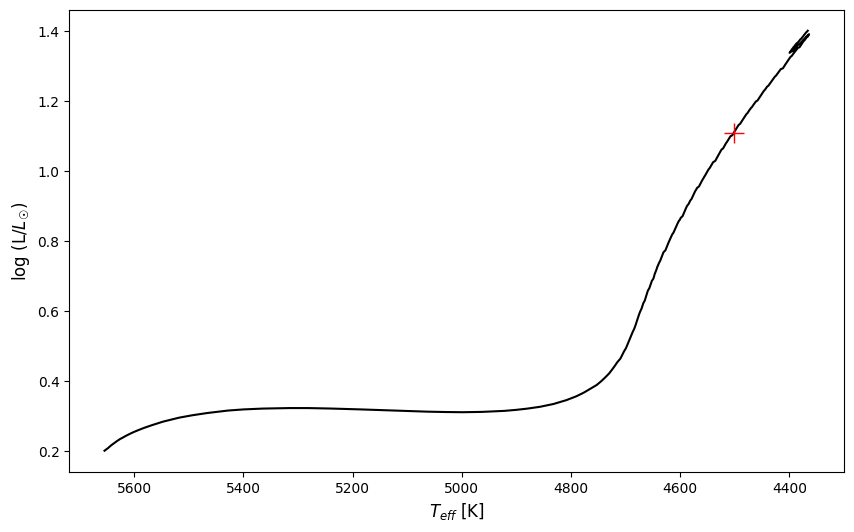

In [ ]:
#@title HRD
plt.figure()
plt.plot(history.Teff,history.log_L,'k')
plt.plot(history.Teff[idx_model_number],history.log_L[idx_model_number],'r+',ms=15)
plt.xlabel('$T_{eff}$ [K]')
plt.ylabel('log (L/$L_\u2609$)')
plt.gca().invert_xaxis()

Δν (Gyre):        9.197532598261391


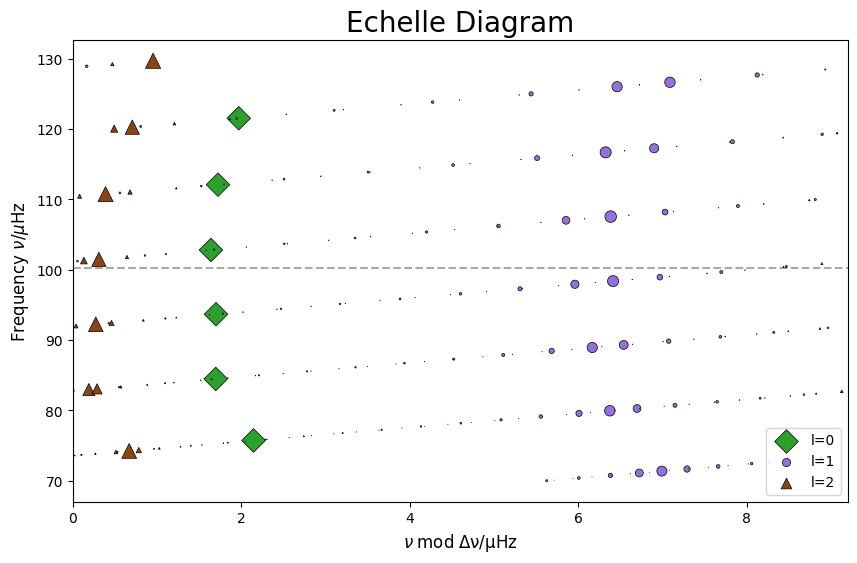

In [ ]:
#@title calculate Δν and plot Echelle
summary       = pg.read_output(f'summary.txt')

modes0 = summary[summary['l'] == 0]
dnu=get_dnu_from_mod(modes0,nu_max,plot=False)

print('Δν (Gyre):       ',dnu)

axEchelle=plot_echelle(summary,nu_max,dnu)


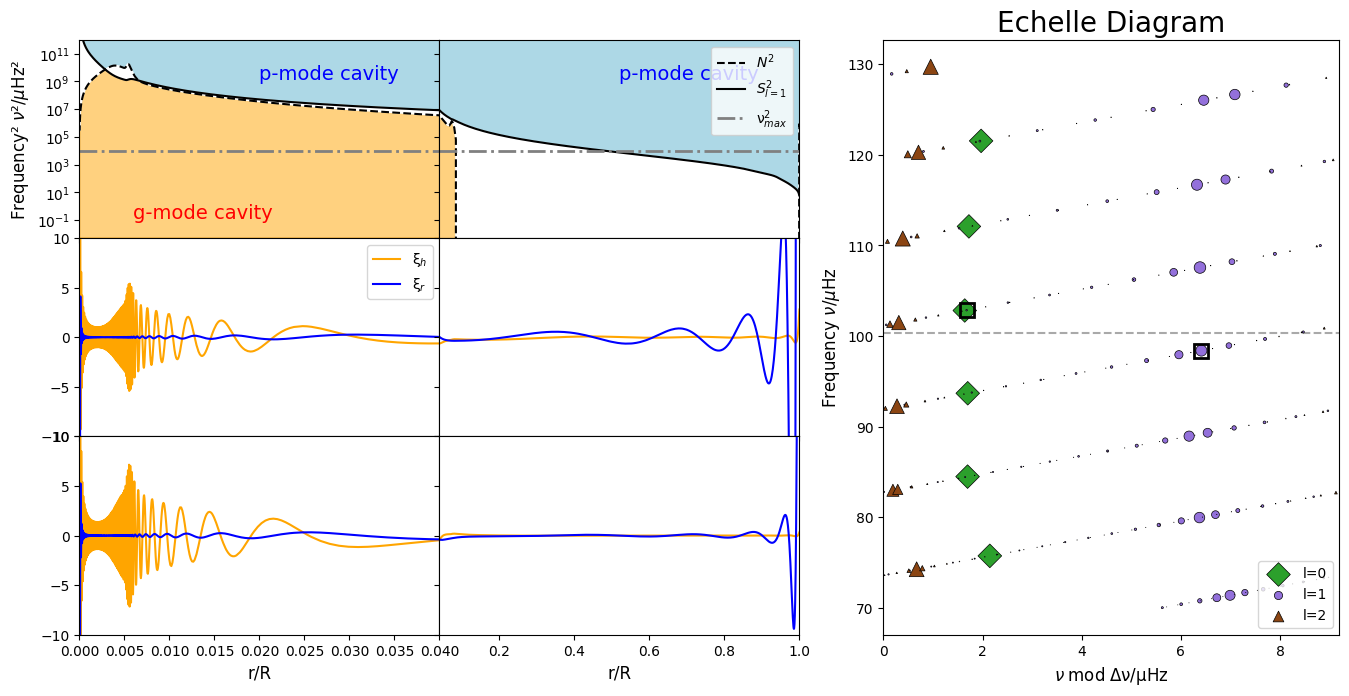

In [ ]:
#@title plot eigenfunctions
profile       = mr.MesaData(   f'profile{i+1}.data')

detail_directory=''#directory+f'gyre{i+1}'

plot_gyre_grid(profile,summary,detail_directory,nu_max,dnu,scale_xi=False,figsize=(14,7)) #<------change figsize if plot too big/small on your laptop

/tmp/ipython-input-10-3688879782.py:200: RuntimeWarning: invalid value encountered in divide
  F=  np.sqrt(omega2 /csound2 + l*(l+1)  * brunt2 / r**2 / omega2)


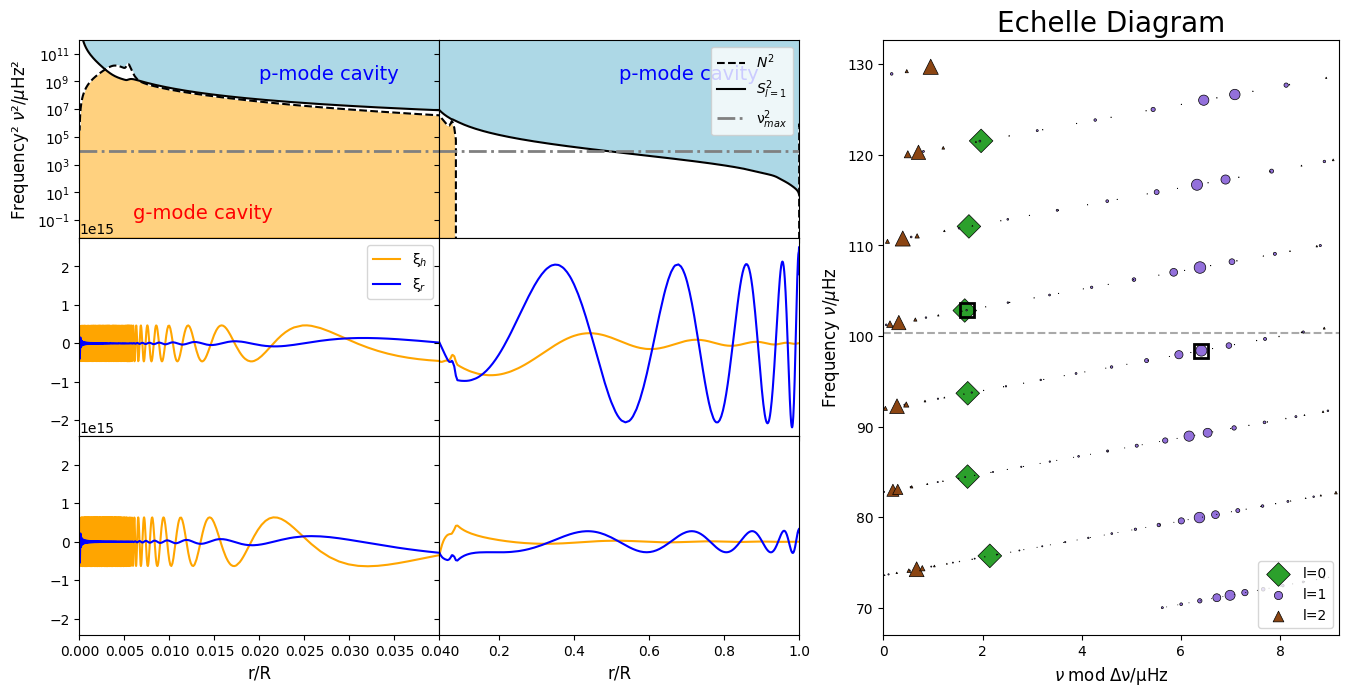

In [ ]:
#@title plot scaled eigenfunctions

plot_gyre_grid(profile,summary,detail_directory,nu_max,dnu,scale_xi=True,figsize=(14,7)) #<------change figsize if plot too big/small on your laptop